In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import time
start_time = time.time()
dataset = pd.read_csv('https://raw.githubusercontent.com/shrikant-temburwar/Wine-Quality-Dataset/master/winequality-red.csv',sep=';' )
dataset


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


array([[<Axes: title={'center': 'fixed acidity'}>,
        <Axes: title={'center': 'volatile acidity'}>,
        <Axes: title={'center': 'citric acid'}>],
       [<Axes: title={'center': 'residual sugar'}>,
        <Axes: title={'center': 'chlorides'}>,
        <Axes: title={'center': 'free sulfur dioxide'}>],
       [<Axes: title={'center': 'total sulfur dioxide'}>,
        <Axes: title={'center': 'density'}>,
        <Axes: title={'center': 'pH'}>],
       [<Axes: title={'center': 'sulphates'}>,
        <Axes: title={'center': 'alcohol'}>,
        <Axes: title={'center': 'quality'}>]], dtype=object)

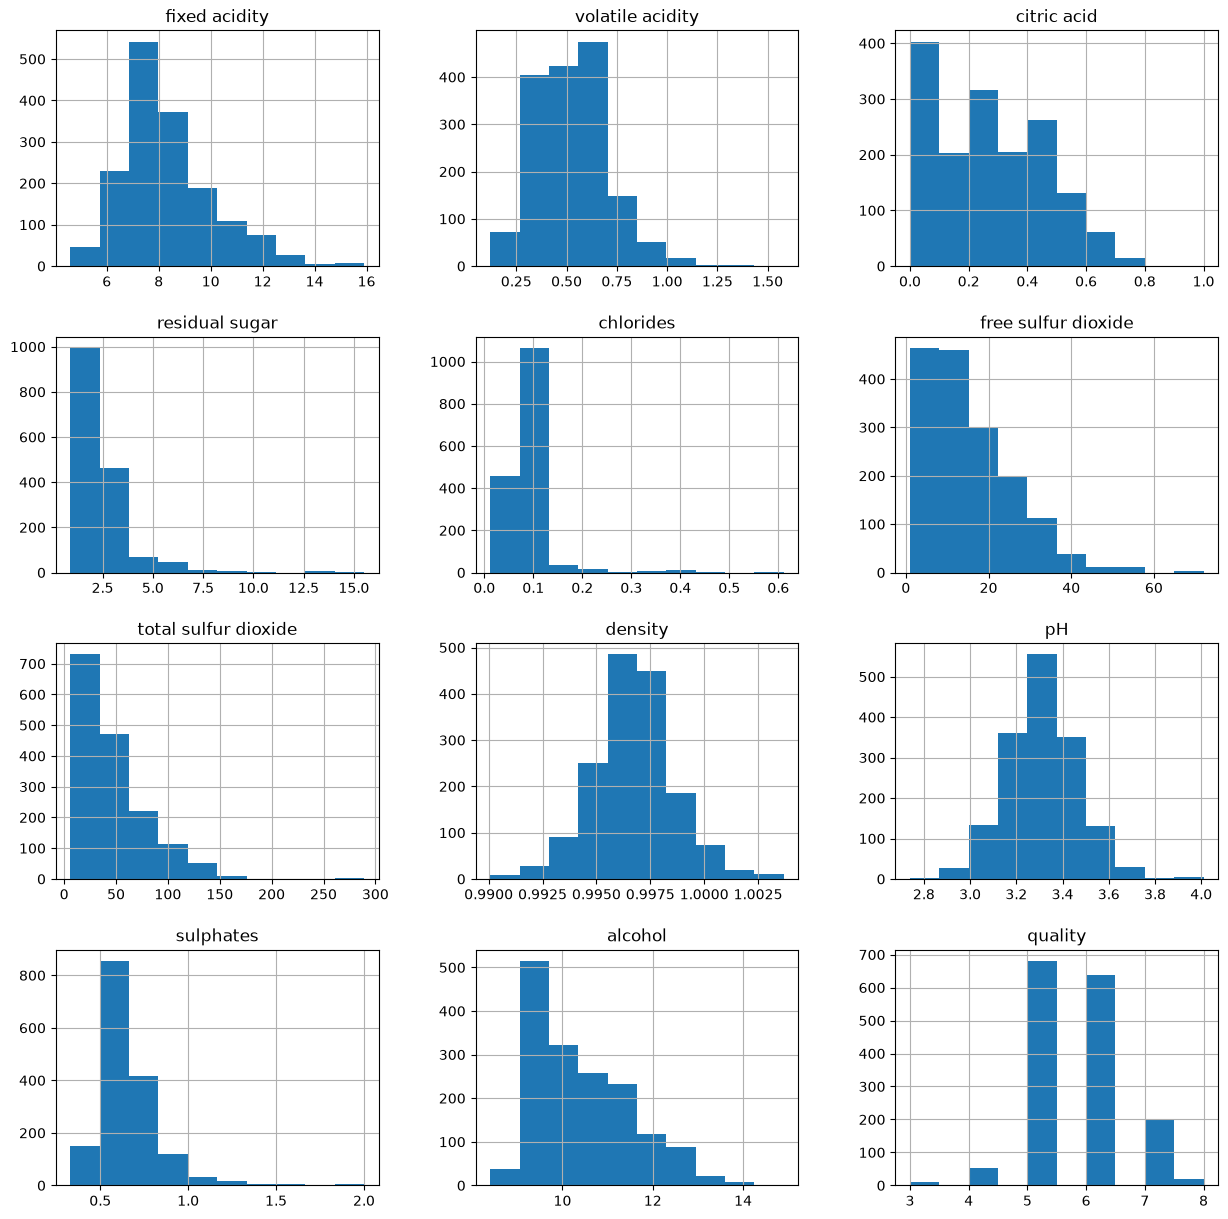

In [2]:
dataset.hist(figsize=(15,15))

In [3]:
def normalizar(x, xmax, xmin, ymax, ymin):
    m = (ymax - ymin) / (xmax - xmin)
    b = ymin - m * xmin
    y = m * x + b
    return y

In [4]:
max = dataset.max().values
min = dataset.min().values
data = normalizar(dataset, max, min, 1, 0)
data.head(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,0.247788,0.397260,0.00,0.068493,0.106845,0.140845,0.098940,0.567548,0.606299,0.137725,0.153846,0.4
1,0.283186,0.520548,0.00,0.116438,0.143573,0.338028,0.215548,0.494126,0.362205,0.209581,0.215385,0.4
2,0.283186,0.438356,0.04,0.095890,0.133556,0.197183,0.169611,0.508811,0.409449,0.191617,0.215385,0.4
3,0.584071,0.109589,0.56,0.068493,0.105175,0.225352,0.190813,0.582232,0.330709,0.149701,0.215385,0.6
4,0.247788,0.397260,0.00,0.068493,0.106845,0.140845,0.098940,0.567548,0.606299,0.137725,0.153846,0.4


In [5]:
x=data.drop('quality',axis=1)
y=data['quality']
x.head(4)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,0.247788,0.397260,0.00,0.068493,0.106845,0.140845,0.098940,0.567548,0.606299,0.137725,0.153846
1,0.283186,0.520548,0.00,0.116438,0.143573,0.338028,0.215548,0.494126,0.362205,0.209581,0.215385
2,0.283186,0.438356,0.04,0.095890,0.133556,0.197183,0.169611,0.508811,0.409449,0.191617,0.215385
3,0.584071,0.109589,0.56,0.068493,0.105175,0.225352,0.190813,0.582232,0.330709,0.149701,0.215385


In [6]:
y.head(4)

0    0.4
1    0.4
2    0.4
3    0.6
Name: quality, dtype: float64

In [7]:
torch.manual_seed(42)

In [8]:
x_train, x_test, y_train, y_test = train_test_split(x.values, y.values, test_size=0.3)
x_train, y_train = torch.tensor(x_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32)
x_test, y_test = torch.tensor(x_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.float32)
input_shape = (x_train.shape[1])
print(input_shape)
# # 1. Split the data first (Re-added this line!)
# x_train, x_test, y_train, y_test = train_test_split(x.values, y.values, test_size=0.3)

# # 2. Convert to tensors
# x_train, y_train = torch.tensor(x_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32)
# x_test, y_test = torch.tensor(x_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.float32)

# input_shape = (x_train.shape[1])
# print(input_shape)


11


In [9]:
class Model(nn.Module):
    def __init__(self, input_dim):
        super(Model, self).__init__()
        self.layer1 = nn.Linear(input_dim, 16)
        self.layer2 = nn.Linear(16, 1)

    def forward(self, x):
        x = nn.functional.relu(self.layer1(x))
        x = self.layer2(x)
        return x
model = Model(x_train.shape[1])
print(model)

Model(
  (layer1): Linear(in_features=11, out_features=16, bias=True)
  (layer2): Linear(in_features=16, out_features=1, bias=True)
)


In [10]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [11]:
num_epochs=50
batch_size= 100
train_losses=[]
test_losses=[]

In [12]:
for epoch in range(num_epochs):
    for i in range(0, x_train.shape[0], batch_size):
        inputs = x_train[i:i+batch_size]
        targets = y_train[i:i+batch_size]
        optimizer.zero_grad()
        outputs = model(inputs)

        loss = criterion(outputs, targets)
        loss.backward()

        optimizer.step()

    train_loss = criterion(model(x_train), y_train)
    train_losses.append(train_loss.item())

    test_loss = criterion(model(x_test), y_test)
    test_losses.append(test_loss.item())
    print(f"Epoch {epoch+1}, train loss: {train_loss.item():.4f}, test loss: {test_loss.item():.4f}")


Epoch 1, train loss: 0.3046, test loss: 0.3094
Epoch 2, train loss: 0.2350, test loss: 0.2393
Epoch 3, train loss: 0.1692, test loss: 0.1731
Epoch 4, train loss: 0.1125, test loss: 0.1159
Epoch 5, train loss: 0.0701, test loss: 0.0727
Epoch 6, train loss: 0.0441, test loss: 0.0458
Epoch 7, train loss: 0.0329, test loss: 0.0336
Epoch 8, train loss: 0.0311, test loss: 0.0311
Epoch 9, train loss: 0.0310, test loss: 0.0309
Epoch 10, train loss: 0.0305, test loss: 0.0305
Epoch 11, train loss: 0.0301, test loss: 0.0303
Epoch 12, train loss: 0.0299, test loss: 0.0300
Epoch 13, train loss: 0.0297, test loss: 0.0298
Epoch 14, train loss: 0.0295, test loss: 0.0296
Epoch 15, train loss: 0.0294, test loss: 0.0295
Epoch 16, train loss: 0.0293, test loss: 0.0294
Epoch 17, train loss: 0.0291, test loss: 0.0292
Epoch 18, train loss: 0.0290, test loss: 0.0291
Epoch 19, train loss: 0.0290, test loss: 0.0291
Epoch 20, train loss: 0.0289, test loss: 0.0290
Epoch 21, train loss: 0.0288, test loss: 0.0289
E

/opt/homebrew/lib/python3.11/site-packages/torch/nn/modules/loss.py:630: UserWarning: Using a target size (torch.Size([100])) that is different to the input size (torch.Size([100, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/opt/homebrew/lib/python3.11/site-packages/torch/nn/modules/loss.py:630: UserWarning: Using a target size (torch.Size([19])) that is different to the input size (torch.Size([19, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/opt/homebrew/lib/python3.11/site-packages/torch/nn/modules/loss.py:630: UserWarning: Using a target size (torch.Size([1119])) that is different to the input size (torch.Size([1119, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.